### **Code used to generate plots in Fig. 2 and Extended Data Fig. 2**

##### This notebook provides an example of the code used to generate plots found in Fig. 2 and Extended Data Fig. 2.

#### **Overview:**

1. Activity quantification with STARR-FISH package
2. Fig. 2 plots
3. Extended Data Fig. 2 plots

#### **Key outputs:**
- Plots of STARR-FISH activity
- Correlations between replicates, STARR-FISH vs STARR-seq, or MERFISH vs RNA-seq
- Differential STARR-FISH activity between cell lines (including heatmaps and scatter plots)

#### **1. Activity quantification with STARR-FISH package**

##### *Import packages*

In [1]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy
import warnings
warnings.filterwarnings('ignore')

##### *Define functions for data processing*

In [21]:
def preprocess_experiment(enhancer_file, vector_file=None, nanopore_file=None, rna_seq_file=None, dna_seq_file=None, bed_file=None):
    enhancer = pd.read_csv(enhancer_file, index_col=0)
    enhancer.index = enhancer.index.astype(str)
    if vector_file is None:
        # use enhancer as vector as a place holder, so that I don't have to change the code
        vector = enhancer.copy()
    else:
        vector = pd.read_csv(vector_file)
    if 'masks' in enhancer.columns and 'fov' in enhancer.columns:
        enhancer.index = enhancer['masks'].astype(str) + '_' + enhancer['fov'].astype(str)
        vector.index = vector['masks'].astype(str) + '_' + vector['fov'].astype(str)
    else:
        # infer mask and fov from the index
        enhancer['fov'] = enhancer.index.str[:-3] + '000'
        enhancer['masks'] = enhancer.index
        vector['fov'] = enhancer.index.str[:-3] + '000'
        vector['masks'] = vector.index
    # find common index and filter
    common_index = enhancer.index.intersection(vector.index)
    enhancer = enhancer.loc[common_index]
    vector = vector.loc[common_index]
    # drop mask and fov columns
    enhancer_drop = enhancer.copy().drop(columns=['masks', 'fov'])
    vector_drop = vector.copy().drop(columns=['masks', 'fov'])
    # check if total transcripts column exists
    if 'total transcripts' not in enhancer_drop.columns:
        enhancer_drop['total transcripts'] = enhancer_drop.sum(axis=1)
        enhancer['total transcripts'] = enhancer_drop['total transcripts']
    if 'total transcripts' not in vector_drop.columns:
        vector_drop['total transcripts'] = vector_drop.sum(axis=1)
        vector['total transcripts'] = vector_drop['total transcripts']
    result = {"enhancer": enhancer_drop, "vector": vector_drop,
              "enhancer_orig": enhancer, "vector_orig": vector}
    result['enhancer_orig'].rename(columns={'total transcripts': 'total_transcripts'}, inplace=True)
    result['vector_orig'].rename(columns={'total transcripts': 'total_transcripts'}, inplace=True)
    # if rna_seq_file and dna_seq_file are provided, add them to the result
    if nanopore_file is not None:
        nanopore = pd.read_csv(nanopore_file, sep=' ', skipinitialspace=True, header=None)
        nanopore.set_index(1, inplace=True)
        # fullfill the index to CRE names
        cre_names = enhancer_drop.columns[enhancer_drop.columns != 'total transcripts']
        result['nanopore'] = nanopore.reindex(cre_names, fill_value=0)
    if rna_seq_file is not None:
        rna_counts = pd.read_csv(rna_seq_file, sep='\t', skipinitialspace=True, skiprows=1)
        rna_counts.set_index('Geneid', inplace=True)
        result['rna_counts'] = rna_counts.iloc[:, -1]
    if dna_seq_file is not None:
        dna_counts = pd.read_csv(dna_seq_file, sep='\t', skipinitialspace=True, skiprows=1)
        dna_counts.set_index('Geneid', inplace=True)
        result['dna_counts'] = dna_counts.iloc[:, -1]
    if bed_file is not None:
        ccre_names = pd.read_csv(bed_file, header=None, sep='\t')
        ccre_names = ccre_names.astype(str)
        ccre_names = (ccre_names[0] + ":" + ccre_names[1] + "-" + ccre_names[2])
        # set index
        ccre_names = pd.DataFrame(ccre_names.values, index=['CRE' + str(i+1).zfill(3) for i in range(len(ccre_names))])
        result['ccre_names'] = ccre_names
    return result

def preprocess_experiment_HCT116(enhancer_file, vector_file=None, nanopore_file=None, rna_seq_file=None, dna_seq_file=None, bed_file=None):
    enhancer = pd.read_csv(enhancer_file, index_col=0)
    if vector_file is None:
        # use enhancer as vector as a place holder, so that I don't have to change the code
        vector = enhancer.copy()
    else:
        vector = pd.read_csv(vector_file)
    if 'masks' in enhancer.columns and 'fov' in enhancer.columns:
        enhancer.index = enhancer['masks'].astype(str) + '_' + enhancer['fov'].astype(str)
        vector.index = vector['masks'].astype(str) + '_' + vector['fov'].astype(str)
    else:
        # infer mask and fov from the index
        enhancer['fov'] = enhancer.index.str.split('-').str[0]
        enhancer['masks'] = enhancer.index.str.split('-').str[1]
        vector['fov'] = vector.index.str.split('-').str[0]
        vector['masks'] = vector.index.str.split('-').str[1]
    # find common index and filter
    common_index = enhancer.index.intersection(vector.index)
    enhancer = enhancer.loc[common_index]
    vector = vector.loc[common_index]
    # drop mask and fov columns
    enhancer_drop = enhancer.copy().drop(columns=['masks', 'fov'])
    vector_drop = vector.copy().drop(columns=['masks', 'fov'])
    # check if total transcripts column exists
    if 'total transcripts' not in enhancer_drop.columns:
        enhancer_drop['total transcripts'] = enhancer_drop.sum(axis=1)
        enhancer['total transcripts'] = enhancer_drop['total transcripts']
    if 'total transcripts' not in vector_drop.columns:
        vector_drop['total transcripts'] = vector_drop.sum(axis=1)
        vector['total transcripts'] = vector_drop['total transcripts']
    result = {"enhancer": enhancer_drop, "vector": vector_drop,
              "enhancer_orig": enhancer, "vector_orig": vector}
    result['enhancer_orig'].rename(columns={'total transcripts': 'total_transcripts'}, inplace=True)
    result['vector_orig'].rename(columns={'total transcripts': 'total_transcripts'}, inplace=True)
    # if rna_seq_file and dna_seq_file are provided, add them to the result
    if nanopore_file is not None:
        nanopore = pd.read_csv(nanopore_file, sep=' ', skipinitialspace=True, header=None)
        nanopore.set_index(1, inplace=True)
        # fullfill the index to CRE names
        cre_names = enhancer_drop.columns[enhancer_drop.columns != 'total transcripts']
        result['nanopore'] = nanopore.reindex(cre_names, fill_value=0)
    if rna_seq_file is not None:
        rna_counts = pd.read_csv(rna_seq_file, sep='\t', skipinitialspace=True, skiprows=1)
        rna_counts.set_index('Geneid', inplace=True)
        result['rna_counts'] = rna_counts.iloc[:, -1]
    if dna_seq_file is not None:
        dna_counts = pd.read_csv(dna_seq_file, sep='\t', skipinitialspace=True, skiprows=1)
        dna_counts.set_index('Geneid', inplace=True)
        result['dna_counts'] = dna_counts.iloc[:, -1]
    if bed_file is not None:
        ccre_names = pd.read_csv(bed_file, header=None, sep='\t')
        ccre_names = ccre_names.astype(str)
        ccre_names = (ccre_names[0] + ":" + ccre_names[1] + "-" + ccre_names[2])
        # set index
        ccre_names = pd.DataFrame(ccre_names.values, index=['CRE' + str(i+1).zfill(3) for i in range(len(ccre_names))])
        result['ccre_names'] = ccre_names
    return result

# glm fit on single experiment, fit enhancer ~ T7
# if norm_by_total, then fit enhancer / total_enhancer ~ vector / total_vector
def glm_fit(experiment, family=sm.families.Gaussian(), use_fov_covariate=True, norm_by_total=False):
    # Create the model
    enhancer = experiment["enhancer"]
    vector = experiment["vector"]
    neg_ctrls = ['CRE' + str(i).zfill(3) for i in range(285, 300)]
    result = pd.DataFrame()
    if norm_by_total:
        enhancer = enhancer.div(enhancer.iloc[:, -1], axis=0)
        vector = vector.div(vector.iloc[:, -1], axis=0)
    for cre in enhancer.columns[:-1]:
        if cre not in vector.columns:
            raise ValueError(f"CRE {cre} not found in vector data.")
        fit_data=pd.DataFrame({'y': enhancer[cre].values, 
                               'x': vector[cre].values,
                               'fov': experiment["enhancer_orig"]['fov'].values})
        if not use_fov_covariate:
            glm_results = smf.ols('y ~ x', fit_data, family=family).fit()
        else:
            glm_results = smf.ols('y ~ x + C(fov)', fit_data, family=family).fit()
        # Fit the model
        glm_summary = pd.read_html(glm_results.summary().tables[1].as_html(), header=0, index_col=0)[0]
        glm_summary = pd.DataFrame(glm_summary.loc['x']).T
        glm_summary.index = [cre]
        result = pd.concat([result, glm_summary], axis=0)
    # do glm fit on poshen data
    poshen = pd.read_excel(r'C:\Users\zgibbs\analysis\zgibbs_local\STARR-seq_Chen_et_al\Poshen_Table_S3.xlsx', sheet_name = "raw counts HCT116")
    poshen['Activity'] = poshen.iloc[:,-3:].mean(axis=1) / poshen.iloc[:,-4]
    poshen.set_index('oligo', inplace=True)
    poshen_deseq2 = pd.read_csv(r'C:\Users\zgibbs\analysis\zgibbs_local\STARR-seq_Chen_et_al\HCT116_activating_oligo.csv')
    poshen_deseq2 = poshen_deseq2.iloc[:-5,:]
    poshen_deseq2.index = poshen_deseq2['chr'].astype(str) + ":" + poshen_deseq2['start'].astype(int).astype(str) + "-" + poshen_deseq2['end'].astype(int).astype(str)
    ccre_names = pd.read_csv(r'C:\Users\zgibbs\analysis\zgibbs_local\300CRE_HCT116_rep1\STARR-FISH_270_library.bed', header=None, sep='\t')
    ccre_names = ccre_names.astype(str)
    poshen = poshen.loc[(ccre_names[0] + ":" + ccre_names[1] + "-" + ccre_names[2])]
    poshen_deseq2 = poshen_deseq2.loc[(ccre_names[0] + ":" + ccre_names[1] + "-" + ccre_names[2])]
    poshen.index = [f'CRE{str(i+1).zfill(3)}' for i in range(len(poshen))]
    poshen_deseq2.index = [f'CRE{str(i+1).zfill(3)}' for i in range(len(poshen))]
    # poshen fill missing values with NA
    poshen = poshen.reindex(result.index, fill_value=np.nan)
    poshen_deseq2 = poshen_deseq2.reindex(result.index, fill_value=np.nan)
    result['Poshen Activity'] = poshen['Activity'].values
    result['Poshen Activity DESeq2'] = poshen_deseq2['lfc'].values
    result['RNA/DNA'] = experiment['rna_counts'].values / experiment['dna_counts'].values
    result['RNA/DNA lfc'] = np.log2(result['RNA/DNA'])
    # rename result
    result = result.rename(columns={'coef': 'STARR-FISH Activity', 'std err': 'STARR-FISH Activity std err'})
    result['log(STARR-FISH Activity)'] = np.log(result['STARR-FISH Activity'])
    experiment['glm_fit_result'] = result
    return experiment

# glm fit on single experiment, fit enhancer ~ total_enhancer, T7 ~ total_T7, 
# then if norm_by_vector, divide the coefficients: enhancer ~ total_enhancer / vector ~ total_vector
# if norm_by_nanopore, divide the enhancer coefficients by log(nanopore counts): enhancer ~ total_enhancer / log(nanopore counts)
def glm_fit_total(experiment, family=sm.families.Gaussian(), norm_by_vector=True, norm_by_nanopore=True, use_fov_covariate=False,
                  sequencing=None, regress_against_neg_ctrls=True, key_add='glm_fit_total_result'):
    # Create the model
    enhancer = experiment["enhancer"]
    vector = experiment["vector"]
    neg_ctrls = ['CRE' + str(i).zfill(3) for i in range(285, 300)]
    enh_result = pd.DataFrame()
    vec_result = pd.DataFrame()
    for cre in enhancer.columns[:-1]:
        if cre not in vector.columns:
            raise ValueError(f"CRE {cre} not found in vector data.")
        
        # can change 'x' to regress against total transcripts or sum of negative controls
        if regress_against_neg_ctrls:
            fit_data=pd.DataFrame({'y': enhancer[cre].values, 
                                   'x': enhancer[neg_ctrls].sum(axis=1).values,
                                   'fov': experiment["enhancer_orig"]['fov'].values})
            
        else:
            fit_data=pd.DataFrame({'y': enhancer[cre].values, 
                                   'x': enhancer['total transcripts'].values,
                                   'fov': experiment["enhancer_orig"]['fov'].values})
        if not use_fov_covariate:
            glm_results = smf.ols('y ~ x', fit_data, family=family).fit()
        else:
            glm_results = smf.ols('y ~ x + C(fov)', fit_data, family=family).fit()
        # Fit the model
        glm_summary = pd.read_html(glm_results.summary().tables[1].as_html(), header=0, index_col=0)[0]
        glm_summary = pd.DataFrame(glm_summary.loc['x']).T
        glm_summary.index = [cre]
        enh_result = pd.concat([enh_result, glm_summary], axis=0)

        # can change 'x' to regress against total transcripts or sum of negative controls
        if regress_against_neg_ctrls:
            fit_data=pd.DataFrame({'y': vector[cre].values, 
                                   'x': vector[neg_ctrls].sum(axis=1).values,
                                   'fov': experiment["vector_orig"]['fov'].values})
        else:
            fit_data=pd.DataFrame({'y': vector[cre].values, 
                                   'x': vector['total transcripts'].values,
                                   'fov': experiment["vector_orig"]['fov'].values})
        if not use_fov_covariate:
            glm_results = smf.ols('y ~ x', fit_data, family=family).fit()
        else:
            glm_results = smf.ols('y ~ x + C(fov)', fit_data, family=family).fit()
        # Fit the model
        glm_summary = pd.read_html(glm_results.summary().tables[1].as_html(), header=0, index_col=0)[0]
        glm_summary = pd.DataFrame(glm_summary.loc['x']).T
        glm_summary.index = [cre]
        vec_result = pd.concat([vec_result, glm_summary], axis=0)
    result = enh_result.copy()
    # result.index = [f'CRE{str(i+1).zfill(3)}' for i in range(len(result))]
    if norm_by_vector:
        result['coef'] = result['coef'].values / vec_result['coef'].values
    if norm_by_nanopore:
        nanopore = pd.read_csv(r'C:\Users\zgibbs\analysis\zgibbs_local\bulk_sequencing\plasmidsaurus_20250213\N5LC7G_3_sample_3_counts', sep=' ', skipinitialspace=True, header=None)
        nanopore.set_index(1, inplace=True)

        OG_ids = nanopore.index # Original IDs from the STARR-FISH library
        new_ids = [f"CRE{int(item[3:]) - 1:03d}" for item in OG_ids] # Convert the original IDs to new IDs that match the cell-by-cre matrix IDs
        nanopore.index = new_ids # Update the 'name' column with the new IDs

        result['nanopore'] = nanopore[0].reindex(result.index).values
        result['coef'] = result['coef'].values / np.log1p(result['nanopore'].values)
    # do glm fit on poshen data
    poshen = pd.read_excel(r'C:\Users\zgibbs\analysis\zgibbs_local\STARR-seq_Chen_et_al\Poshen_Table_S3.xlsx', sheet_name = "raw counts HCT116")
    poshen['Activity'] = poshen.iloc[:,-3:].mean(axis=1) / poshen.iloc[:,-4]
    poshen.set_index('oligo', inplace=True)
    poshen_deseq2 = pd.read_csv(r'C:\Users\zgibbs\analysis\zgibbs_local\STARR-seq_Chen_et_al\HCT116_activating_oligo.csv')
    poshen_deseq2 = poshen_deseq2.iloc[:-5,:]
    poshen_deseq2.index = poshen_deseq2['chr'].astype(str) + ":" + poshen_deseq2['start'].astype(int).astype(str) + "-" + poshen_deseq2['end'].astype(int).astype(str)
    ccre_names = pd.read_csv(r'C:\Users\zgibbs\analysis\zgibbs_local\300CRE_HCT116_rep1\STARR-FISH_270_library.bed', header=0, sep='\t')
    ccre_names = ccre_names.astype(str)
    poshen = poshen.loc[(ccre_names.iloc[:,0] + ":" + ccre_names.iloc[:,1] + "-" + ccre_names.iloc[:,2])]
    poshen_deseq2 = poshen_deseq2.reindex(poshen.index)
    poshen.index = ccre_names['name']
    poshen_deseq2.index = ccre_names['name']
    # poshen fill missing values with NA
    poshen = poshen.reindex(result.index, fill_value=np.nan)
    poshen_deseq2 = poshen_deseq2.reindex(result.index, fill_value=np.nan)
    result['Poshen Activity'] = poshen['Activity'].values
    result['Poshen Activity DESeq2'] = poshen_deseq2['lfc'].values
    if sequencing is not None:
        result['RNA/DNA'] = experiment['rna_counts'].values / experiment['dna_counts'].values
        result['RNA/DNA lfc'] = np.log2(result['RNA/DNA'])
    result = result.rename(columns={'coef': 'STARR-FISH Activity', 'std err': 'STARR-FISH Activity std err'})
    result['log(STARR-FISH Activity)'] = np.log(result['STARR-FISH Activity'])
    experiment[key_add] = result
    return experiment

def plot_activity(glm_result, value='STARR-FISH Activity', std='STARR-FISH Activity std err', cre_names=['CRE015', 'CRE016'], top_cres=['CRE043', 'CRE094', 'CRE046'], fig_name=None, ax=None):
    if ax is None:
        plt.figure(figsize=(6, 5))
        ax = plt.gca()
    else:
        plt.sca(ax)

    sorted_data = glm_result.sort_values(by=value, ascending=False)
    sorted_data = sorted_data[sorted_data.index.isin(cre_names)]

    bins = np.arange(len(sorted_data))
    bin_centers = (bins + bins) / 2
    y_means = np.array(sorted_data[value])
    y_sems = np.array(sorted_data[std])
    plt.fill_between(bin_centers,
                    y_means - y_sems,
                    y_means + y_sems,
                    color='gray',
                    alpha=0.3, edgecolor='k', lw=1)
    
    sns.scatterplot(data=sorted_data, x=np.arange(len(sorted_data)), y=value, color='olive',
                    marker='o', edgecolor='k', alpha=0.8, lw=0.75, s=30, label='cCREs')
    
    x_positions = sorted_data.index.get_indexer_for(top_cres)
    sns.scatterplot(data=sorted_data.loc[top_cres], x=x_positions, y=value, color='magenta',
                    marker='o', edgecolor='k', alpha=0.8, lw=0.75, s=30, label='Yeast ORFs')
    
    plt.ylabel('STARR-FISH Activity')
    ax.set_xticks([])
    # ax.set_xticklabels(None)

    # remove x label
    plt.xlabel('')
    plt.legend(frameon=False)
    plt.tight_layout()

    # save figure
    if fig_name is not None:
        plt.savefig(rf'C:\Users\zgibbs\STARR-FISH\figures\STARR-FISH_ms_figure_2\{fig_name}')
    return ax

##### *Process the data and calculate enhancer activity*

In [7]:
# preprocess data
WTC11 = preprocess_experiment(enhancer_file=r'C:\Users\zgibbs\analysis\zgibbs_local\cell_by_gene\SFv6_WTC11_D3_enhancer_cbg.csv',
                                    vector_file=None,
                                    nanopore_file=r'C:\Users\zgibbs\analysis\zgibbs_local\bulk_sequencing\plasmidsaurus_20250213\N5LC7G_3_sample_3_counts',
                                    rna_seq_file=None,
                                    dna_seq_file=None,
                                    bed_file=r'C:\Users\zgibbs\analysis\zgibbs_local\300CRE_HCT116_rep1\STARR-FISH_270_library.bed')

HCT116 = preprocess_experiment_HCT116(enhancer_file=r'C:\Users\zgibbs\analysis\zgibbs_local\cell_by_gene\SFv6_cell_by_CRE_01_04_2023.csv',
                                    vector_file=None,
                                    nanopore_file=r'C:\Users\zgibbs\analysis\zgibbs_local\bulk_sequencing\plasmidsaurus_20250213\N5LC7G_3_sample_3_counts',
                                    rna_seq_file=None,
                                    dna_seq_file=None,
                                    bed_file=r'C:\Users\zgibbs\analysis\zgibbs_local\300CRE_HCT116_rep1\STARR-FISH_270_library.bed')

HCT116_rep = preprocess_experiment_HCT116(enhancer_file=r'C:\Users\zgibbs\analysis\zgibbs_local\cell_by_gene\SFv6_cell_by_CRE_03_19_2023.csv',
                                    vector_file=None,
                                    nanopore_file=r'C:\Users\zgibbs\analysis\zgibbs_local\bulk_sequencing\plasmidsaurus_20250213\N5LC7G_3_sample_3_counts',
                                    rna_seq_file=None,
                                    dna_seq_file=None,
                                    bed_file=r'C:\Users\zgibbs\analysis\zgibbs_local\300CRE_HCT116_rep1\STARR-FISH_270_library.bed')

# fit glm
WTC11_fit = glm_fit_total(WTC11, family=sm.families.Gaussian(), norm_by_vector=False, norm_by_nanopore=True,
                                regress_against_neg_ctrls=False, key_add='glm_fit_total_result_nanopore')
HCT116_fit = glm_fit_total(HCT116, family=sm.families.Gaussian(), norm_by_vector=False, norm_by_nanopore=True,
                                regress_against_neg_ctrls=False, key_add='glm_fit_total_result_nanopore')
HCT116_rep_fit = glm_fit_total(HCT116_rep, family=sm.families.Gaussian(), norm_by_vector=False, norm_by_nanopore=True,
                                regress_against_neg_ctrls=False, key_add='glm_fit_total_result_nanopore')

#### **1. Fig. 2 plots**

##### *Fig. 2d: STARR-FISH activity distribution*

<Axes: ylabel='STARR-FISH Activity'>

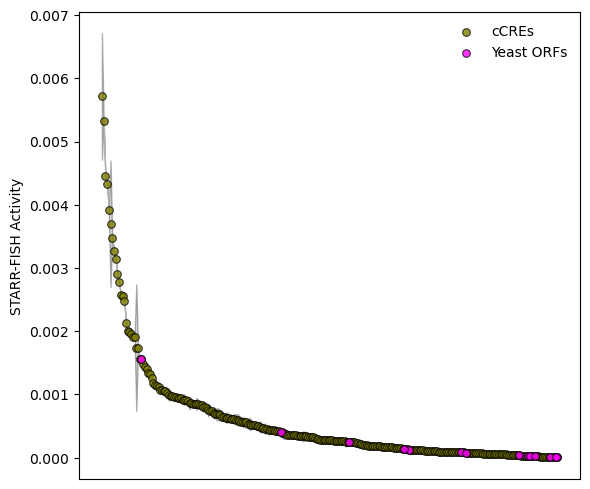

In [27]:
cre_names = ['CRE' + str(i).zfill(3) for i in range(15, 300)]
neg_ctrls = ['CRE' + str(i).zfill(3) for i in range(285, 300)]
top_cres = ['CRE043', 'CRE094', 'CRE046']

plot_activity(HCT116_fit['glm_fit_total_result_nanopore'], cre_names=cre_names, top_cres=neg_ctrls, fig_name=None)

##### *Fig. 2e: Activity correlation between replicates in HCT116*

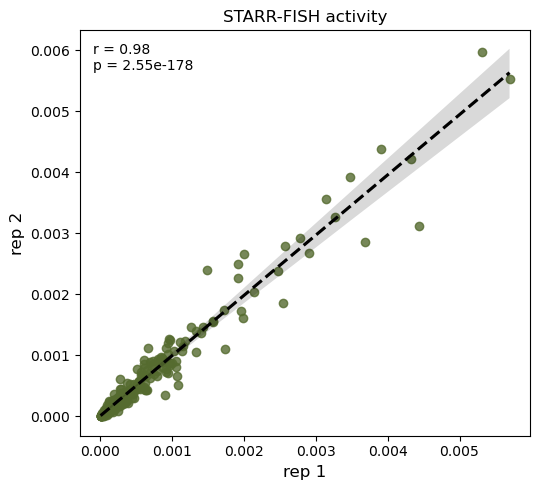

In [34]:
from matplotlib.offsetbox import AnchoredText
from scipy import stats
import seaborn as sns

fig, ax = plt.subplots(figsize=(5.5,5))

x = HCT116_fit['glm_fit_total_result_nanopore']['STARR-FISH Activity']
y = HCT116_rep_fit['glm_fit_total_result_nanopore']['STARR-FISH Activity']

mask = np.isfinite(x) & np.isfinite(y)

x = np.log1p(x[mask])
y = np.log1p(y[mask])

sns.regplot(x=x, y=y,
            color='darkolivegreen',
            line_kws={'ls' : 'dashed', 'color' : 'k'})

ax.set_xlabel('rep 1', fontsize=12)
ax.set_ylabel('rep 2', fontsize=12)
ax.set_title('STARR-FISH activity', fontsize=12)

stats = stats.pearsonr(x, y)

corrcoef = np.around(stats[0], 2)
pval = np.format_float_scientific(stats[1], 2)

anchored_text = AnchoredText(f"r = {corrcoef}\np = {pval}", loc=2, frameon=False)
ax.add_artist(anchored_text)

plt.tight_layout()
plt.show()

##### *Fig. 2f: Differential STARR-FISH activity heatmap for HCT116 vs WTC11*

In [40]:
# Cluster STARR-FISH activity data from experiments based on log2 FC between HCT116 and WTC11
df = pd.DataFrame({'HCT116': HCT116_fit['glm_fit_total_result_nanopore']['STARR-FISH Activity'],
                  'WTC11': WTC11_fit['glm_fit_total_result_nanopore']['STARR-FISH Activity']})

keep = np.isfinite(df['HCT116']) & np.isfinite(df['WTC11'])
df = df[keep]

df['log2FC'] = np.log2((df['HCT116']) / (df['WTC11']))

df['Cluster'] = pd.cut(df['log2FC'],
                       bins=[-np.inf, -1.5, 1.5, np.inf],
                       labels=['WTC11_specific', 'non-specific', 'HCT116_specific'])

df['avg_activity'] = df[['HCT116', 'WTC11']].max(axis=1)
df['diff_activity'] = np.abs(df['log2FC'])

# Sort by cluster for visualization
df_sorted = df.sort_values(by=['Cluster', 'avg_activity'], ascending=[False, False])

# re-sort the dataframe by Cluster (non-specific, HCT116_specific, WTC11_specific)
custom_order = ['HCT116_specific', 'WTC11_specific', 'non-specific']
df_sorted['Cluster'] = pd.Categorical(df_sorted['Cluster'], categories=custom_order, ordered=True)
df_sorted_resorted = df_sorted.sort_values(by='Cluster')

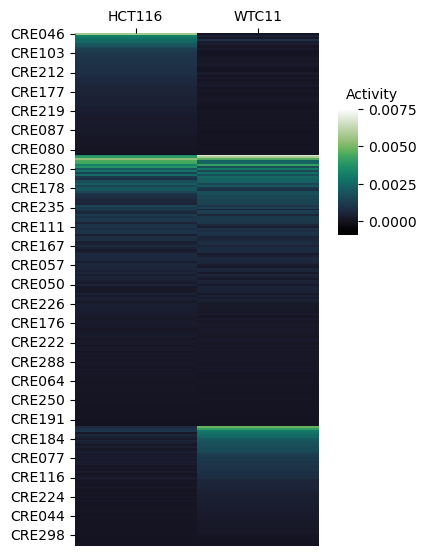

In [41]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import cmasher as cmr

keep = df_sorted['avg_activity'] > 0

g = sns.clustermap(df_sorted.loc[keep, ['HCT116', 'WTC11']], cmap=cmr.swamp, figsize=(4, 7),
                   col_cluster=False, row_cluster=False,
                   cbar_kws={'label': 'STARR-FISH Activity'},
                   cbar_pos=(0.85, 0.5, 0.05, 0.18), vmin=-0.0009, 
                   vmax=0.0075
                   )

g.ax_row_dendrogram.set_visible(False)
g.ax_col_dendrogram.set_visible(False)
g.ax_heatmap.yaxis.set_ticks_position('left')
g.ax_heatmap.yaxis.set_label_position('left')
g.ax_heatmap.xaxis.set_ticks_position('top')
g.ax_heatmap.xaxis.set_label_position('top')

g.cax.set_ylabel('')

g.figure.text(
    x=g.cax.get_position().x0 + g.cax.get_position().width / 2 + 0.06,  # center of colorbar
    y=g.cax.get_position().y1 + 0.01,  # a bit above the top of the colorbar
    s='Activity',  # label text
    ha='center',
    va='bottom'
)

plt.show()

##### *Fig. 2g-i: Activity plots for HCT116 and WTC11 with cluster or ATAC log2FC indicated*

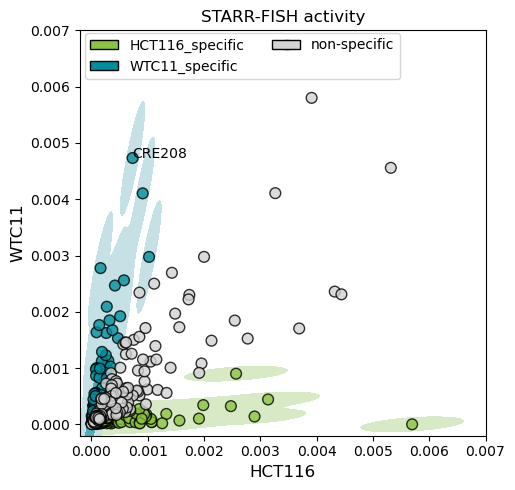

In [65]:
from matplotlib.offsetbox import AnchoredText
from scipy import stats
import seaborn as sns
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(5.5,5))

# melt starr-fish activity dataframe for plotting purposes
df_melted = df_sorted_resorted[['HCT116', 'WTC11']].reset_index().melt(id_vars='index', var_name='Cell line', value_name='STARR-FISH Activity')
df_melted_merge = df_melted.merge(df_sorted_resorted[['Cluster']], left_on='index', right_index=True)

# extract x and y values for HCT116 and WTC11
x = df_melted_merge['STARR-FISH Activity'][df_melted_merge['Cell line'] == 'HCT116']
y = df_melted_merge['STARR-FISH Activity'][df_melted_merge['Cell line'] == 'WTC11']
x = np.log1p(x)
y = np.log1p(y)

colors = {'HCT116_specific' : '#8BC53F', 'WTC11_specific' : '#008F9F', 'non-specific' : 'lightgray'}

sns.regplot(x=x, y=y, fit_reg=False,
            color='olive',
            line_kws={'ls' : 'dashed', 'color' : 'k', 'zorder' : 3},
            scatter_kws={'color' : [colors[i] for i in df_melted_merge['Cluster'][df_melted_merge['Cell line'] == 'HCT116']],
                         'linewidths' : 1, 's' : 60, 'edgecolor' : 'k', 'zorder' : 2})

# KDE contours
for cluster, color in colors.items():
    if cluster == 'non-specific':
        continue 

    subset = df_melted_merge[df_melted_merge['Cluster'] == cluster]
    pivoted = subset.pivot(index='index', columns='Cell line', values='STARR-FISH Activity').dropna()
    pivoted['HCT116'] = np.log1p(pivoted['HCT116'])
    pivoted['WTC11'] = np.log1p(pivoted['WTC11'])

    if {'HCT116', 'WTC11'}.issubset(pivoted.columns):
        sns.kdeplot(
            data=pivoted, x='HCT116', y='WTC11',
            fill=True, alpha=1, thresh=0.01, levels=3,
            cmap=sns.light_palette(color, as_cmap=True), zorder=1, linewidths=1
        )

ax.set_xlabel('HCT116', fontsize=12)
ax.set_ylabel('WTC11', fontsize=12)
ax.set_title('STARR-FISH activity', fontsize=12)

ax.set_aspect('equal')
ax.set_xlim(-0.0002,0.007)
ax.set_ylim(-0.0002,0.007)


# add labels to each point on the scatter plot
idx = df_sorted_resorted.index.get_loc('CRE208')
ax.annotate(df_sorted_resorted.index[idx], (x[idx], y[idx+266]))

# for i, txt in enumerate(df_sorted.index):
#     ax.annotate(txt, (x[idx], y[idx+252]))

stats = stats.pearsonr(x, y)

corrcoef = np.around(stats[0], 2)
pval = np.format_float_scientific(stats[1], 2)

anchored_text = AnchoredText(f"r = {corrcoef}\np = {pval}", loc=2, frameon=False)
# ax.add_artist(anchored_text)

# create legend handles manually
legend_handles = [Patch(facecolor=col, edgecolor='k', label=label) for label, col in colors.items()]
plt.legend(handles=legend_handles, frameon=True, loc='upper center', bbox_to_anchor=(0.4, 1.011), ncol=2)

plt.tight_layout()
plt.show()

In [71]:
# define ccre_names
ccre_names = pd.read_csv(r'C:\Users\zgibbs\analysis\zgibbs_local\300CRE_HCT116_rep1\STARR-FISH_270_library.bed', header=0, sep='\t')
ccre_names = ccre_names.astype(str)
ccre_names['enhancer id'] = ccre_names['chr'].astype(str) + ":" + ccre_names['start'].astype(int).astype(str) + "-" + ccre_names['end'].astype(int).astype(str)

# load ATAC-seq tag counts for both cell lines calculated using HOMER
homer = pd.read_table(r'C:\Users\zgibbs\analysis\zgibbs_local\bulk_sequencing\ATAC\annotatePeaks_ATAC_new.txt')
homer.rename(columns={'HCT116_ATAC_tags_new/ Tag Count in 500 bp (26201497.0 Total, normalization factor = 0.38, effective total = 10000000)' : 'HCT116_ATAC_tags',
                      'WTC11_ATAC_tags_new/ Tag Count in 500 bp (27662508.0 Total, normalization factor = 0.36, effective total = 10000000)' : 'WTC11_ATAC_tags',
                      'WTC11_d14_ATAC_tags_new/ Tag Count in 500 bp (34934207.0 Total, normalization factor = 0.29, effective total = 10000000)' : 'WTC11_d14_ATAC_tags',
                      'PeakID (cmd=annotatePeaks.pl STARR-FISH_270_library_HOMER.bed hg38 -size 500 -d HCT116_ATAC_tags_new/ WTC11_ATAC_tags_new/ WTC11_d14_ATAC_tags_new/)' : 'CRE'}, inplace=True)
homer.set_index('CRE', inplace=True)
homer = homer.reindex(df_sorted_resorted.index)

# add ATAC-seq tag counts to the sorted dataframe
df_sorted_atac = df_sorted_resorted.copy()
df_sorted_atac['HCT116_ATAC_tags'] = homer['HCT116_ATAC_tags'].values
df_sorted_atac['WTC11_ATAC_tags'] = homer['WTC11_ATAC_tags'].values
df_sorted_atac['WTC11_d14_ATAC_tags'] = homer['WTC11_d14_ATAC_tags'].values
df_sorted_atac['Entrez ID'] = homer['Entrez ID'].values
df_sorted_atac['Ensembl ID'] = homer['Nearest Ensembl'].values

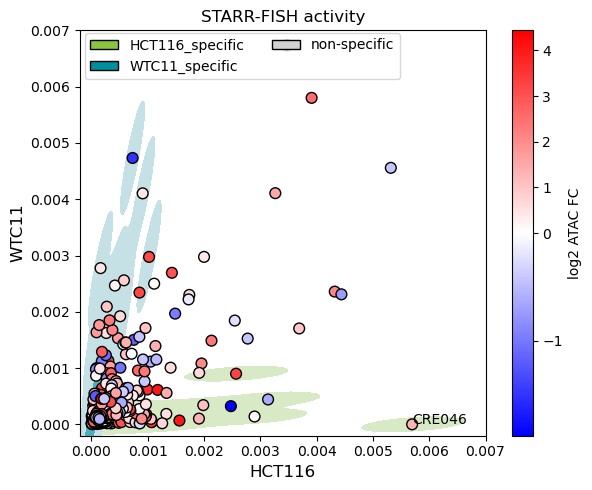

In [74]:
from matplotlib.offsetbox import AnchoredText
from scipy import stats
import seaborn as sns
from matplotlib.patches import Patch
from matplotlib.colors import TwoSlopeNorm

fig, ax = plt.subplots(figsize=(6.3,5))

x = df_melted_merge['STARR-FISH Activity'][df_melted_merge['Cell line'] == 'HCT116']
y = df_melted_merge['STARR-FISH Activity'][df_melted_merge['Cell line'] == 'WTC11']

x = np.log1p(x)
y = np.log1p(y)

colors = {'HCT116_specific' : '#8BC53F', 'WTC11_specific' : '#008F9F', 'non-specific' : 'lightgray'}

sns.regplot(x=x, y=y, fit_reg=False, scatter=False,
            color='olive',
            line_kws={'ls' : 'dashed', 'color' : 'k', 'zorder' : 3},
            scatter_kws={'color' : [colors[i] for i in df_melted_merge['Cluster'][df_melted_merge['Cell line'] == 'HCT116']],
                         'linewidths' : 1, 's' : 60, 'edgecolor' : 'k', 'zorder' : 2})

# Plot scatter plot based on STARR-FISH activity,
# but each point is colored based on its ATAC signal (log2 fold change)
df_sorted_atac['atac FC'] = np.log2((df_sorted_atac['HCT116_ATAC_tags'] + 1) / (df_sorted_atac['WTC11_ATAC_tags'] + 1))
atac_diff = df_sorted_atac['atac FC']
cmap = plt.cm.bwr
norm = TwoSlopeNorm(vmin=-1.88, vcenter=0, vmax=4.44)
sc = plt.scatter(
    x, y,
    c=atac_diff,                
    cmap=cmap,
    norm=norm,       
    s=60, edgecolors='k',
    linewidths=1,
    zorder=2
)

plt.colorbar(sc, label='log2 ATAC FC')

# KDE contours
for cluster, color in colors.items():
    if cluster == 'non-specific':
        continue

    subset = df_melted_merge[df_melted_merge['Cluster'] == cluster]
    pivoted = subset.pivot(index='index', columns='Cell line', values='STARR-FISH Activity').dropna()

    if {'HCT116', 'WTC11'}.issubset(pivoted.columns):
        sns.kdeplot(
            data=pivoted, x='HCT116', y='WTC11',
            fill=True, alpha=1, thresh=0.01, levels=3,
            cmap=sns.light_palette(color, as_cmap=True), zorder=1, linewidths=1
        )

ax.set_xlabel('HCT116', fontsize=12)
ax.set_ylabel('WTC11', fontsize=12)
ax.set_title('STARR-FISH activity', fontsize=12)

ax.set_aspect('equal')
ax.set_xlim(-0.0002,0.007)
ax.set_ylim(-0.0002,0.007)

# add labels to each point on the scatter plot
idx = df_sorted_resorted.index.get_loc('CRE046')
ax.annotate(df_sorted_resorted.index[idx], (x[idx], y[idx+266]))

stats = stats.pearsonr(x, y)

corrcoef = np.around(stats[0], 2)
pval = np.format_float_scientific(stats[1], 2)

anchored_text = AnchoredText(f"r = {corrcoef}\np = {pval}", loc=2, frameon=False)
# ax.add_artist(anchored_text)

# create legend handles manually
legend_handles = [Patch(facecolor=col, edgecolor='k', label=label) for label, col in colors.items()]
plt.legend(handles=legend_handles, frameon=True, loc='upper center', bbox_to_anchor=(0.4, 1.011), ncol=2)

plt.tight_layout()
plt.show()

#### **2. Extended Data Fig. 2 plots**

##### *Extended Data Fig. 2a-b: Correlations between STARR-FISH and sequencing-based quantification*

In [77]:
# Load in featureCounts table from bulk RNA-seq sample
RNAseq = pd.read_csv(r'C:\Users\zgibbs\analysis\zgibbs_local\bulk_sequencing\HCT116_300CRE_rep1\CRE300_BC_featureCounts_output.txt', sep = '\t', header=1)
RNAseq2 = pd.read_csv(r'C:\Users\zgibbs\analysis\zgibbs_local\bulk_sequencing\HCT116_300CRE_rep2\CRE300_BC_featureCounts_output.txt', sep = '\t', header=1)
RNAseq3 = pd.read_csv(r'C:\Users\zgibbs\analysis\zgibbs_local\bulk_sequencing\WTC11_D3_SFv6\WTC11_D3_SFv6_rep1_featureCounts_output.txt', sep = '\t', header=1)

# Change name of last column
RNAseq = RNAseq.rename(columns={'/tscc/projects/ps-renlab2/zgibbs/STARR-FISH/RNAseq/CRE300_rep1/dedup.aligned_BC_reads_CRE300_rep1.bam': 'Counts'})
RNAseq2 = RNAseq2.rename(columns={'/tscc/projects/ps-renlab2/zgibbs/STARR-FISH/RNAseq/CRE300_rep2/dedup.aligned_BC_reads_CRE300_rep2.bam': 'Counts'})
RNAseq3 = RNAseq3.rename(columns={'/tscc/projects/ps-renlab2/zgibbs/STARR-FISH/RNAseq/WTC11_SFv6_rep1/dedup.aligned_reads.bam': 'Counts'})

# Make a new column for calculated cpm of each CRE transcript
# use the total number of reads from bulk RNA-seq sample here
RNAseq['cpm'] = (RNAseq['Counts'].div(64143345))*1000000 
RNAseq2['cpm'] = (RNAseq2['Counts'].div(69137386))*1000000 
RNAseq3['cpm'] = (RNAseq3['Counts'].div(30060988))*1000000 

RNAseq['neg ctrl normalized'] = RNAseq['Counts'] / RNAseq.iloc[-15:,-2].mean()
df_merge = pd.merge(HCT116_fit['glm_fit_total_result_nanopore'], RNAseq, left_index=True, right_on='Geneid')
df_merge['RNA-seq neg ctrl and nanopore norm'] = df_merge['neg ctrl normalized'] / np.log1p(df_merge['nanopore'])
df_merge['RNA-seq nanopore norm'] = df_merge['Counts'] / np.log1p(df_merge['nanopore'])

RNAseq2['neg ctrl normalized'] = RNAseq2['Counts'] / RNAseq2.iloc[-15:,-2].mean()
df_merge2 = pd.merge(HCT116_fit['glm_fit_total_result_nanopore'], RNAseq2, left_index=True, right_on='Geneid')
df_merge2['RNA-seq neg ctrl and nanopore norm'] = df_merge2['neg ctrl normalized'] / np.log1p(df_merge2['nanopore'])
df_merge2['RNA-seq nanopore norm'] = df_merge2['Counts'] / np.log1p(df_merge2['nanopore'])

RNAseq3['neg ctrl normalized'] = RNAseq3['Counts'] / RNAseq3.iloc[-15:,-2].mean()
df_merge3 = pd.merge(WTC11_fit['glm_fit_total_result_nanopore'], RNAseq3, left_index=True, right_on='Geneid')
df_merge3['RNA-seq neg ctrl and nanopore norm'] = df_merge3['neg ctrl normalized'] / np.log1p(df_merge3['nanopore'])
df_merge3['RNA-seq nanopore norm'] = df_merge3['Counts'] / np.log1p(df_merge3['nanopore'])

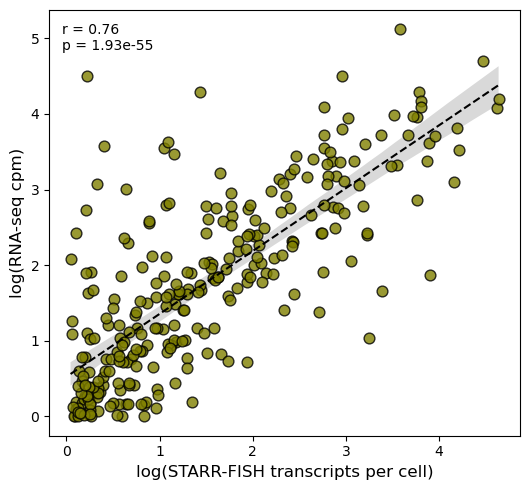

In [122]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import Divider, Size
from scipy import stats

fig, ax = plt.subplots(figsize=(5.4, 5))

keep = (df_merge['nanopore'] >= 1) & (df_merge['STARR-FISH Activity'] >= 0.00005)
x = np.log1p((HCT116_fit['enhancer'].iloc[:,:285].mean(axis=0).values + HCT116_rep_fit['enhancer'].iloc[:,:285].mean(axis=0).values) / 2)
y = np.log1p((df_merge['cpm'] + df_merge2['cpm']) / 2)
mask = np.isfinite(x) & np.isfinite(y)

sns.regplot(x=x[mask], y=y[mask], fit_reg=True, scatter=True,
            color='olive',
            line_kws={'ls' : 'dashed', 'color' : 'k', 'zorder' : 3, 'linewidth' : 1.5},
            scatter_kws={'color' : 'olive',
                         'linewidths' : 1, 's' : 60, 'edgecolor' : 'k', 'zorder' : 2})

ax.set_xlabel('log(STARR-FISH transcripts per cell)', fontsize=12)
ax.set_ylabel('log(RNA-seq cpm)', fontsize=12)

stats = stats.spearmanr(x, y)
corrcoef = np.around(stats[0], 2)
pval = np.format_float_scientific(stats[1], 2)
anchored_text = AnchoredText(f"r = {corrcoef}\np = {pval}", loc=2, frameon=False)
ax.add_artist(anchored_text)

plt.tight_layout()
plt.show()

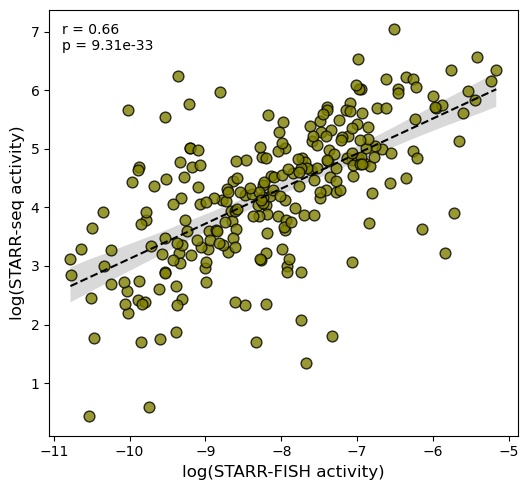

In [121]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import Divider, Size
from scipy import stats

fig, ax = plt.subplots(figsize=(5.4, 5))

keep = (df_merge['nanopore'] >= 1) & (df_merge['STARR-FISH Activity'] >= 0.00002)
x = np.log((df_merge['STARR-FISH Activity'][keep] + df_merge2['STARR-FISH Activity'][keep]) / 2)
y = np.log((df_merge['RNA-seq nanopore norm'][keep] + df_merge2['RNA-seq nanopore norm'][keep]) / 2)
mask = np.isfinite(x) & np.isfinite(y)

sns.regplot(x=x[mask], y=y[mask], fit_reg=True, scatter=True,
            color='olive',
            line_kws={'ls' : 'dashed', 'color' : 'k', 'zorder' : 3, 'linewidth' : 1.5},
            scatter_kws={'color' : 'olive',
                         'linewidths' : 1, 's' : 60, 'edgecolor' : 'k', 'zorder' : 2})

ax.set_xlabel('log(STARR-FISH activity)', fontsize=12)
ax.set_ylabel('log(STARR-seq activity)', fontsize=12)

stats = stats.spearmanr(x, y)
corrcoef = np.around(stats[0], 2)
pval = np.format_float_scientific(stats[1], 2)
anchored_text = AnchoredText(f"r = {corrcoef}\np = {pval}", loc=2, frameon=False)
ax.add_artist(anchored_text)

plt.tight_layout()
plt.show()